# IMA Project

In [89]:
# Imports and plotting configuration
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io
import scipy

plt.rcParams['figure.figsize'] = (10, 6)

In [90]:
DATA_DIR = Path(__file__).parent.joinpath('..').resolve() / 'assets' if '__file__' in globals() else Path('..') / 'assets'
# default paths (adjust if needed)
IMAGE_REF = DATA_DIR / 'image_ref.jpg'
IMAGE_DENOISED_OUT = DATA_DIR / 'image_denoised.jpg'
IMAGE_BLURRED_OUT = DATA_DIR / 'image_blurred.jpg'


kernel_derivation_x = None
kernel_derivation_y = None

def load_and_prepare_image(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f'Image not found: {path}')
    h, w = img.shape[:2]
    # keep as-is but convert BGR->RGB for plotting
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [91]:
def add_noise(image, sigma=20, scale=0.6):
    """Add Gaussian noise to an image and clip to uint8."""
    noise = sigma * np.random.normal(0, scale, image.shape)
    N = np.clip((image + noise).astype(np.int64), 0, 255).astype(np.uint8)
    return N

def simple_custom_blur(image, kernel = None):
    """Apply a small custom directional kernel blur (keeps channels)."""
    cus = image.copy()
    if kernel is None:
        kernel = np.array([[0, 0, 0, 0, 1],
                        [0, 0, 0, 0, 1],
                        [1, 1, 1, 1, 1],
                        [0, 0, 0, 0, 1],
                        [0, 0, 0, 0, 1]])

    kernel_base = kernel / np.sum([np.sum(i) for i in kernel])
    B = np.array(cv2.filter2D(cus, -1, cv2.flip(kernel_base, -1)))
    return B

def denoise_colored_image(noisy_image, h=10, hColor=10, templateWindowSize=7, searchWindowSize=15):
    """Denoise a color image using OpenCV's Non-local Means (fastNlMeansDenoisingColored)."""
    return cv2.fastNlMeansDenoisingColored(noisy_image, None, h, hColor, templateWindowSize, searchWindowSize)

In [92]:
def kernel_vers_grand(k, n, m):
   p = len(k)
   N = (len(k)+1)//2
   M = len(k)-N

   out = np.zeros((n, m))
   out[0:N,0:N] =k[M:p,M:p]
   out[-M:,-M:] =k[0:M,0:M]
   out[-M:,0:N] =k[0:M,M:p]
   out[0:N,-M:] =k[M:p,0:M]
   return out

def soft_threshold_one_coordinate(lambd, x):
  if x > lambd :
    return x - lambd
  elif abs(x) <= lambd :
    return 0
  else:
    return x + lambd

def soft_threshold(lambd, M):
  return np.array([[soft_threshold_one_coordinate(lambd, M[i][j]) for j in range(len(M[0]))] for i in range(len(M))])

def minimizer_soft_threshold(lambd, U, rho):
  return soft_threshold(lambd/rho, U)

def convolution_circulaire(img1, img2):
    if img1.shape != img2.shape:
        raise ValueError(f'Les deux images doivent avoir la même taille. Trouvé {img1.shape} et {img2.shape}.')
    F1 = np.fft.fft2(img1)
    F2 = np.fft.fft2(img2)
    conv_hat = F1 * F2
    conv_circ = np.real(np.fft.ifft2(conv_hat))
    return conv_circ

In [93]:
# Pour résoudre les équations (fonction donné par le prof)
def resoud_quad_fourier(K, V, lambd=0):
    n = len(K)
    assert n == len(V), 'Nombre de filtres K et dimages V différent.'

    sy, sx = K[0].shape
    numer = np.zeros((sy, sx), dtype=np.complex128)
    denom = np.zeros((sy, sx), dtype=np.float64)

    fft2 = np.fft.fft2
    ifft2 = np.fft.ifft2

    for k in range(n):
        fV = fft2(V[k])
        fK = fft2(K[k])
        numer += np.conj(fK) * fV
        denom += np.abs(fK) ** 2

    denom = np.where(denom == 0, 1e-12, denom)
    im_recon = np.real(ifft2(numer / (denom)))
    return im_recon

def convert_large_kernel_to_real_kernel(big_kernel, p):
    n, m = big_kernel.shape
    if p > n or p > m:
        raise ValueError(f'La taille p={p} dépasse celle du grand noyau ({n}, {m}).')

    mini = np.zeros((p, p), dtype=big_kernel.dtype)
    mid_y = (p + 1) // 2
    mid_x = (p + 1) // 2
    mini[mid_y-1:, mid_x-1:] = big_kernel[:p - mid_y+1, :p - mid_x+1]
    mini[mid_y-1:, :mid_x-1] = big_kernel[:p - mid_y+1, m - mid_x+1:]
    mini[:mid_y-1, mid_x-1:] = big_kernel[n - mid_y+1:, :p - mid_x+1]
    mini[:mid_y-1, :mid_x-1] = big_kernel[n - mid_y+1:, m - mid_x+1:]
    return mini

def gradient(image, output_bw=False):
    kernel_used_x = kernel_derivation_x
    kernel_used_y = kernel_derivation_y
    if output_bw and len(image.shape) == 3:
        image = np.mean(image, axis=2)
    elif len(image.shape) == 3:
        kernel_used_x = np.repeat(kernel_derivation_x[:, :, np.newaxis], image.shape[2], axis=2)
        kernel_used_y = np.repeat(kernel_derivation_y[:, :, np.newaxis], image.shape[2], axis=2)
    # kernel_derivation_x/y will be defined in the next cell when sizes are known
    grad_x = convolution_circulaire(image, kernel_used_x)
    grad_y = convolution_circulaire(image, kernel_used_y)
    return [grad_x, grad_y]

def array_to_list(array):
  liste = []
  for i in range(len(array)):
    for j in range(len(array[0])):
      liste.append(array[i][j])
  return liste

def normal_projection_kernel(kernel, taille_support):
    n, m = kernel.shape
    proj = np.zeros_like(kernel)
    N = (taille_support+1)//2
    M = taille_support - N
    elt_save_tl = array_to_list([[(i, j) for j in range(N)] for i in range(N)])
    elt_save_tr = array_to_list([[(i, j) for j in range(m-M, m)] for i in range(N)])
    elt_save_bl = array_to_list([[(i, j) for j in range(N)] for i in range(n-M, n)])
    elt_save_br = array_to_list([[(i, j) for j in range(m-M, m)] for i in range(n-M, n)])
    elt_save = elt_save_bl + elt_save_br + elt_save_tl + elt_save_tr
    for coord in elt_save:
        i,j = coord
        proj[i][j] = np.maximum(kernel[i][j], 0)
    s = proj.sum()
    if s > 0:
      proj = proj / s
    return proj

In [94]:

def admm(nabla_b, nalba_l_chapeau, lambd, taille_noyau=7, seuil=1e-8, rho=10, max_iter=100):
  energy_values = []
  du_values = []
  def energy(u):
    term1 = (np.linalg.norm(convolution_circulaire(nalba_l_chapeau[0], u) - nabla_b[0])**2 +
             np.linalg.norm(convolution_circulaire(nalba_l_chapeau[1], u) - nabla_b[1])**2)
    term2 = lambd * np.sum(np.abs(u))
    return term1 + term2
  n,m = nabla_b[0].shape
  u = np.zeros((n, m))
  u_new = u.copy()
  x = np.zeros((n, m))
  z = np.zeros((n, m))
  v = u
  i=0
  while  i==0 or (np.linalg.norm(u_new-u, 2) > seuil and i < max_iter):
    u = u_new
    x = resoud_quad_fourier([nalba_l_chapeau[0],nalba_l_chapeau[1], [[1]]], [nabla_b[0], nabla_b[1], v])
    v = z-u
    z = minimizer_soft_threshold(lambd, v, rho)
    v = x+u
    u_new = normal_projection_kernel(u + x-z, taille_noyau)
    i+= 1
    energy_values.append(energy(u_new))
    du_values.append(np.linalg.norm(u_new-u, 2))
    print(np.linalg.norm(u_new-u, 2))
  return u_new, energy_values, du_values

def admm2(blurred, nalba_l_chapeau, kernel, lambd, beta, seuil=1e-8, rho=1.0, max_iter=100):
    n,m = blurred.shape
    u_x, u_y = np.zeros((n, m)), np.zeros((n, m))
    u_x_new, u_y_new= np.zeros((n, m)), np.zeros((n, m))
    x = np.zeros((n, m))
    z_x, z_y = np.zeros((n, m)), np.zeros((n, m))
    v_x, v_y = np.zeros((n, m)), np.zeros((n, m))
    i=0
    while  i==0 or (np.linalg.norm(u_y-u_y_new, 'fro') + np.linalg.norm(u_x-u_x_new, 'fro') > seuil and i < max_iter):
      print(np.linalg.norm(u_y-u_y_new, 'fro') + np.linalg.norm(u_x-u_x_new, 'fro'))
      u_x, u_y = u_x_new, u_y_new
      v_x = z_x - u_x
      v_y = z_y - u_y
      x = resoud_quad_fourier([kernel, kernel_derivation_x, kernel_derivation_y], [blurred, v_x, v_y])
      v_x = convolution_circulaire(x, kernel_derivation_x) + u_x
      v_y = convolution_circulaire(x, kernel_derivation_y) + u_y
      z_x = minimizer_soft_threshold(lambd, (v_x + nalba_l_chapeau[0])/(2*beta + rho), 2*beta + rho)
      z_y = minimizer_soft_threshold(lambd, (v_y + nalba_l_chapeau[1])/(2*beta + rho), 2*beta + rho)
      x = np.clip(x, 0, 255)
      u_x_new = u_x + convolution_circulaire(x, kernel_derivation_x) - z_x
      u_y_new = u_y + convolution_circulaire(x, kernel_derivation_y) - z_y
      i+= 1
    print(np.linalg.norm(u_y-u_y_new, 'fro') + np.linalg.norm(u_x-u_x_new, 'fro'))
    return x

In [124]:
def whole_algo(input_blurry, input_noisy, taille_noyau=7):
    global kernel_derivation_x, kernel_derivation_y
    n, m, _ = input_blurry.shape
    input_blurry = np.array(input_blurry, dtype=np.float64)
    kernel_derivation_x = kernel_vers_grand(np.array([[0, 0, 0],[1, 0, -1],[0, 0, 0]]), n, m)
    kernel_derivation_y = kernel_vers_grand(np.array([[0, 1, 0],[0, 0, 0],[0, -1, 0]]), n, m)
    deblurred = denoise_colored_image(input_noisy)
    gradient_blurred = gradient(input_blurry)
    for i in range(5):
        gradient_denoised = gradient(deblurred)
        print(gradient_denoised[0].shape)
        print("Iteration ", i, "en cours...")
        kernel = admm(np.mean(gradient_blurred, axis=3), np.mean(gradient_denoised, axis=3), 0.2, seuil=1e-2 , max_iter=4, taille_noyau=taille_noyau)[0]
        kernel = kernel / np.sum([np.sum(i) for i in kernel])
        gradient_denoised = np.array(gradient_denoised, dtype=np.float64)
        deblurred_red = admm2(input_blurry[:,:,0], gradient_denoised[:,:,:,0], kernel, 0.2, 0.49, seuil=1 , max_iter=5)
        deblurred_green = admm2(input_blurry[:,:,1], gradient_denoised[:,:,:,1], kernel, 0.2, 0.49, seuil=1 , max_iter=5)
        deblurred_blue = admm2(input_blurry[:,:,2], gradient_denoised[:,:,:,2], kernel, 0.2, 0.49, seuil=1 , max_iter=5)
        deblurred = np.stack((deblurred_red, deblurred_green, deblurred_blue), axis=2)
        gradient_denoised = gradient(deblurred)
    return deblurred, kernel

Loaded image shape (Height,Width,Channels): (768, 1024, 3)
Using grayscale shape (n,m)= (768, 1024)
0.27701666050509216
0.003546311891818215
0.0029816163727658463
0.0018107391406813904
0.0010638350032506933
0.0006822817192189654


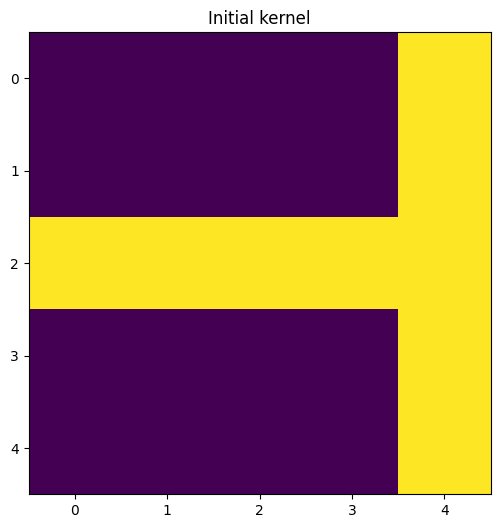

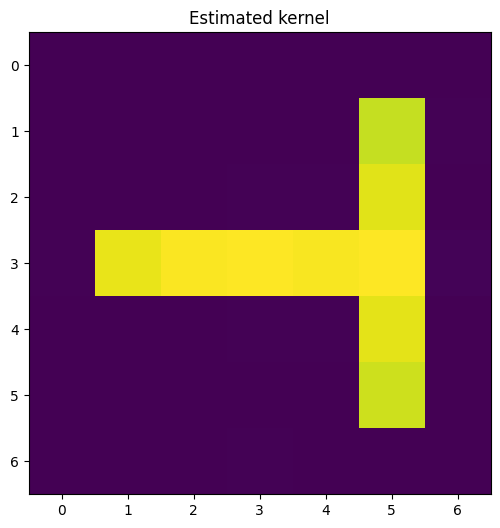

In [96]:
image = load_and_prepare_image(IMAGE_REF)
print('Loaded image shape (Height,Width,Channels):', image.shape)

# Convert to grayscale for kernel estimation / ADMM (use OpenCV for proper luminance)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float64)
n, m = gray.shape
print('Using grayscale shape (n,m)=', (n, m))

# Build derivative kernels that match the actual image size
kernel_derivation_x = kernel_vers_grand(np.array([[0, 0, 0],[1, 0, -1],[0, 0, 0]]), n, m)
kernel_derivation_y = kernel_vers_grand(np.array([[0, 1, 0],[0, 0, 0],[0, -1, 0]]), n, m)

# Create blurred / noisy / denoised versions and convert to grayscale for the solver
initial_kernel = np.array([[0, 0, 0, 0, 1],
                    [0, 0, 0, 0, 1],
                    [1, 1, 1, 1, 1],
                    [0, 0, 0, 0, 1],
                    [0, 0, 0, 0, 1]])
B = simple_custom_blur(image, initial_kernel)
N = add_noise(image)
DN = denoise_colored_image(N)

# Compute gradients (these expect 2D inputs) and run a short ADMM test
gradient_blurred = gradient(B, True)
gradient_denoised = gradient(DN, True)
taille_noyau = 7

# Use a small number of iterations for a quick test; increase for full runs
kernel, energies, du = admm(gradient_blurred, gradient_denoised, lambd=0.15, seuil=1e-3, max_iter=10, taille_noyau=taille_noyau)
noyau = convert_large_kernel_to_real_kernel(kernel, taille_noyau)
plt.imshow(initial_kernel)
plt.title('Initial kernel')
plt.show()
plt.imshow(noyau)
plt.title('Estimated kernel')
plt.show()
## Save the estimated kernel image
io.imsave(DATA_DIR / 'kernel_estimation/estimated_kernel.png', (noyau / np.max(noyau) * 255).astype(np.uint8))
## Save the initial kernel image
io.imsave(DATA_DIR / 'kernel_estimation/initial_kernel.png', (initial_kernel * 255).astype(np.uint8))
## Save the energy values and du plot in a csv
import pandas as pd
energy_df = pd.DataFrame({'Iteration': range(len(energies)), 'Energy': energies, 'Du': du})
energy_df.to_csv(DATA_DIR / 'kernel_estimation/energy_du_values.csv', index=False)

### Now with our own images

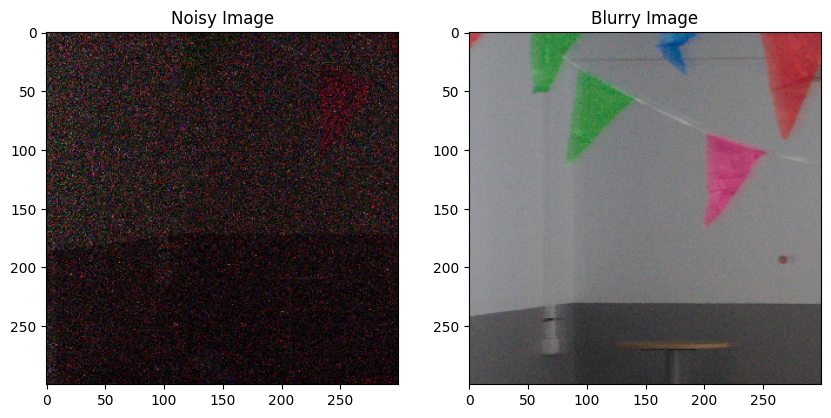

In [147]:

noisy = cv2.imread(DATA_DIR / "home-made/A7S00014.jpg")
if noisy is None:
    raise FileNotFoundError('Image not found')
h, w = noisy.shape[:2]
blurry = cv2.imread(DATA_DIR / "home-made/A7S00013.jpg")
if noisy is None:
    raise FileNotFoundError('Image not found')

## Resize the images to be 1/3 of the original size for faster processing
ratio = 4
noisy = cv2.resize(noisy, (w//ratio, h//ratio))
blurry = cv2.resize(blurry, (w//ratio, h//ratio))

size = 300
offset = (200, 50)
## take only the middle square of size 300x300 offseted by offset
noisy = noisy[offset[1]:offset[1]+size, offset[0]:offset[0]+size]
blurry = blurry[offset[1]:offset[1]+size, offset[0]:offset[0]+size]

h, w = noisy.shape[:2]

## Multiply the noisy because it is underilluminated
noisy = np.clip(noisy.astype(np.float64) * 10., 0, 255).astype(np.uint8)

## convert colors from BGR to RGB for plotting
noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)
blurry = cv2.cvtColor(blurry, cv2.COLOR_BGR2RGB)

## Show both images side by side
plt.subplot(1, 2, 1)
plt.imshow(noisy)
plt.title('Noisy Image')
plt.subplot(1, 2, 2)
plt.imshow(blurry)
plt.title('Blurry Image')
plt.show()


(300, 300, 3)
Iteration  0 en cours...
0.3843763730530396
0.015145420072366366
0.012458735703561341
0.0067224340771602385
0.0
3414.9227627575447
1652.4254586180466
1239.398645426335
1080.0891234375106
986.5478234214461
0.0
3382.0811765306794
1549.037896228039
1077.4826310709373
910.1113771557324
823.3760980761649
0.0
3425.2662998116302
1512.0036169778327
961.4610952768152
755.7508006696481
669.3169484567602
(300, 300, 3)
Iteration  1 en cours...
0.36613049373593753
0.013446290289753547
0.014990757948381854
0.01325115485784563
0.0
6281.456397198789
4354.242978223925
4024.2551218552735
3519.5135931728164
3073.5669428561323
0.0
6284.032664645861
4017.4906637012214
3726.5946956749576
3291.0036358646494
2912.042045669269
0.0
6330.178264742723
3557.1356241129984
3299.9097997321164
2975.1958122475544
2692.957692525959
(300, 300, 3)
Iteration  2 en cours...
0.37429673279833797
0.013616049859819701
0.015102549432493048
0.013405658431663997
0.0
6421.8634953961255
4247.6412835281335
3646.46294764

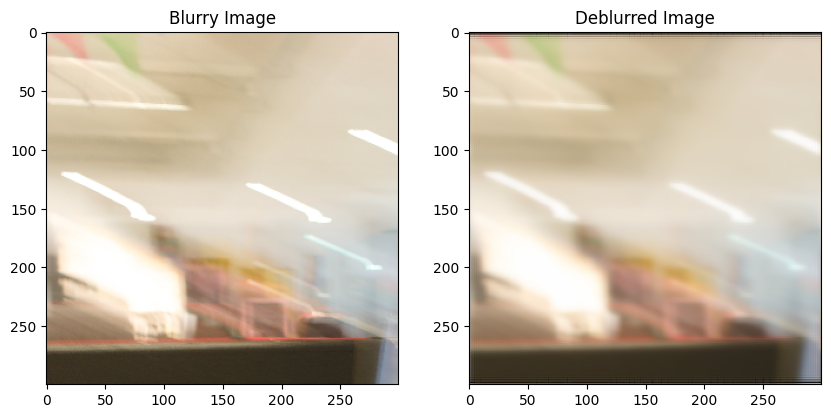

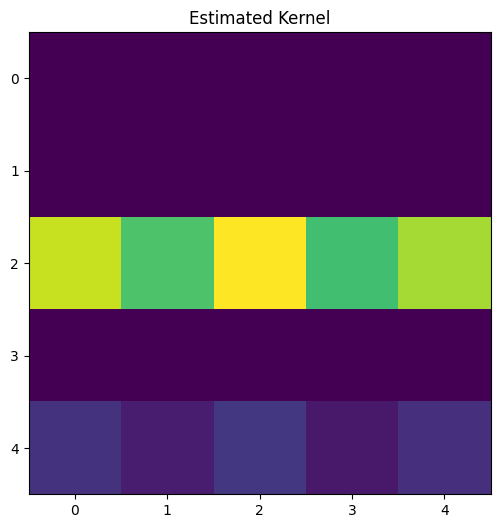

In [146]:
image_result, kernel = whole_algo(blurry, noisy, taille_noyau=5)

## Compare side by side the image and the result
plt.subplot(1, 2, 1)
plt.imshow(blurry.astype(np.uint8))
plt.title('Blurry Image')
plt.subplot(1, 2, 2)
plt.imshow(image_result.astype(np.uint8))
plt.title('Deblurred Image')
plt.show()


kernel = convert_large_kernel_to_real_kernel(kernel, 5)
plt.imshow(kernel)
plt.title('Estimated Kernel')
plt.show()